Clone the YOLOX repo fork and my YOLO-Oneshot repo

In [1]:
!git clone https://github.com/bryanolmstead-vr/YOLOX-fork.git
!git clone https://github.com/bryanolmstead-vr/YOLOX-OneShot.git

Cloning into 'YOLOX-fork'...
remote: Enumerating objects: 2309, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 2309 (delta 46), reused 55 (delta 24), pack-reused 2225 (from 2)
Receiving objects: 100% (2309/2309), 7.71 MiB | 15.20 MiB/s, done.
Resolving deltas: 100% (1403/1403), done.
Cloning into 'YOLOX-OneShot'...
remote: Enumerating objects: 1533, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 1533 (delta 5), reused 12 (delta 3), pack-reused 1513 (from 2)
Receiving objects: 100% (1533/1533), 286.93 MiB | 29.76 MiB/s, done.
Resolving deltas: 100% (123/123), done.
Updating files: 100% (1627/1627), done.


In [2]:
%cd YOLOX-fork
!git checkout obb360
%cd ../YOLOX-OneShot
!git checkout trainOBB
%cd /
!ls

/content/YOLOX-fork
Branch 'obb360' set up to track remote branch 'obb360' from 'origin'.
Switched to a new branch 'obb360'
/content/YOLOX-OneShot
Branch 'trainOBB' set up to track remote branch 'trainOBB' from 'origin'.
Switched to a new branch 'trainOBB'
/
bin			    kaggle		      opt		 sys
boot			    lib			      proc		 tmp
content			    lib32		      python-apt	 tools
cuda-keyring_1.1-1_all.deb  lib64		      python-apt.tar.xz  usr
datalab			    libx32		      root		 var
dev			    media		      run
etc			    mnt			      sbin
home			    NGC-DL-CONTAINER-LICENSE  srv


install YOLOX dependencies

In [3]:
%cd /content/YOLOX-fork
# Install core dependencies first
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install opencv-python loguru tqdm pycocotools tabulate psutil tensorboard thop ninja onnx onnx-simplifier==0.5.0

# Install the rest
!pip install -v -e . --no-deps

/content/YOLOX-fork
Looking in indexes: https://download.pytorch.org/whl/cu118
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 92.5 MB/s eta 0:00:00
  Created wheel for onnx-simplifier: filename=onnx_simplifier-0.5.0-py3-none-any.whl size=1021 sha256=a7a9fd911dc613ff6369b3a7024d2834324fe61fc02dd6945c4c569a224cf3ea
  Stored in directory: /root/.cache/pip/wheels/f0/61/52/656a88deb2107e0239543f2bdfab560c47fcf74c3d29765c5e
Successfully built onnx-simplifier
Using pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
Obtaining file:///content/YOLOX-fork
  Running command python setup.py egg_info
  

In [4]:
# verify yolox version
import yolox
print("YOLOX version:", yolox.__version__)

YOLOX version: 0.3.0


In [5]:
# get YOLO pretrained weights
!wget -P ./YOLOX_outputs https://github.com/Megvii-BaseDetection/YOLOX/releases/download/0.1.1rc0/yolox_s.pth

--2026-03-14 03:35:24--  https://github.com/Megvii-BaseDetection/YOLOX/releases/download/0.1.1rc0/yolox_s.pth
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/386811486/42c4cb47-f94e-475b-a3a2-57f31f26fa5d?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-14T04%3A09%3A34Z&rscd=attachment%3B+filename%3Dyolox_s.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-14T03%3A09%3A32Z&ske=2026-03-14T04%3A09%3A34Z&sks=b&skv=2018-11-09&sig=XxWLex7FHJY7Dz8k75DyngDm0Hx9WLGZDOeY9gOTUR8%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MzQ2MTEyNCwibmJmIjoxNzczNDU5MzI0LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ib

In [6]:
# verify the GPU is still there
!nvidia-smi

Sat Mar 14 03:35:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
!pip install wandb
import wandb

wandb.login()  # will prompt you for API key

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: olmsteab (olmsteab-oregon-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Number of images: 116
Classes: ('candy', 'cards', 'cheeto')
Image 8 id=[9], original size=(640, 640), labels:
 [[340.49984    312.50012    286.44864    115.27776      0.75473287
    0.        ]]


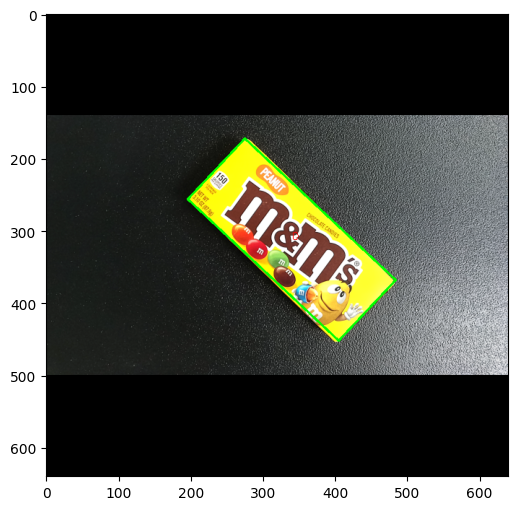

In [ ]:
# visualize that the data is being loaded correctly
from yolox.data.datasets.obb import OBBDataset  # adjust import path if needed
import matplotlib.pyplot as plt
import cv2
import copy

# initialize dataset
dataset = OBBDataset(
    data_dir="/content/YOLOX-OneShot/datasets/OBB360",
    json_file="instances_train2017.json",
    name="train2017",
    img_size=(640, 640),
    preproc=None,  # skip augmentation for debugging
    cache=False
)

print("Number of images:", len(dataset))
print("Classes:", dataset._classes)

for i in range(8,9):  # check 1 image
    img, labels, orig_size, img_id = dataset.pull_item(i)
    print(f"Image {i} id={img_id}, original size={orig_size}, labels:\n", labels)

    img_viz = img.copy()
    for label in labels:
        xc, yc, w, h, angle, cls = label
        # convert angle to degrees for OpenCV
        angle_deg = angle * 180 / 3.14159265

        # draw rotated rectangle
        rect = ((xc, yc), (w, h), angle_deg)
        box = cv2.boxPoints(rect)
        box = box.astype(int)
        cv2.polylines(img_viz, [box], isClosed=True, color=(0,255,0), thickness=2)
        cv2.putText(img_viz, str(int(cls)), (int(xc), int(yc)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)

    # convert BGR to RGB for matplotlib
    img_viz = cv2.cvtColor(img_viz, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,6))
    plt.imshow(img_viz)
    plt.show()

In [ ]:
# do a single pass on the CPU to confirm all the data is working
# then do a small amount of training
try:
    del yolox.models.yolo_head
except:
    pass

import importlib
import yolox.models.yolo_head as yolo_head
importlib.reload(yolo_head)

import torch
from yolox.exp import get_exp
from yolox.data.datasets.obb import OBBDataset
from yolox.data.data_augment import ValTransform  # simple preprocessing

# -----------------------------
# 1) Setup CPU device
# -----------------------------
device = torch.device("cpu")

# -----------------------------
# 2) Load experiment and model
# -----------------------------
exp_file = "/content/YOLOX-fork/exps/example/custom/yolox_s_obb_3classes.py"
exp = get_exp(exp_file)
model = exp.get_model().to(device)
model.train()  # set to train mode to compute loss
torch.set_printoptions(precision=1, sci_mode=False)

# -----------------------------
# 3) Load dataset
# -----------------------------
dataset = OBBDataset(
    data_dir="/content/YOLOX-OneShot/datasets/OBB360",
    json_file="instances_train2017.json",
    name="train2017",
    img_size=(640, 640),
    preproc=ValTransform(),  # just simple resize / normalization
    cache=False
)

# -----------------------------
# 4) Grab a single sample
# -----------------------------
img, labels, orig_size, img_id = dataset.pull_item(0)
print(f"raw labels of shape {labels.shape}: {labels}")

# Convert image to torch tensor
img = torch.from_numpy(img).float().unsqueeze(0)      # [1,H,W,C]
img = img.permute(0, 3, 1, 2).to(device)             # [1,3,H,W]

# Convert labels to tensor
labels = torch.from_numpy(labels).unsqueeze(0).float().to(device)  # [1,num_objs,6]
print(f"tensor of shape {labels.shape}: {labels}")

# -----------------------------
# 5) Compute YOLOX OBB loss
# -----------------------------
outputs = model(img, labels)  # train mode
print("Total loss:", outputs["total_loss"].item())
print("IOU loss:", outputs["iou_loss"].item())
print("Cls loss:", outputs["cls_loss"].item())

# 6) do a small training run

batch_size = 1  # or 2 if memory allows
num_batches = 3  # just to see the loss evolution
print(f"training for {num_batches} batches:")
for i in range(num_batches):
    img, labels, orig_size, img_id = dataset.pull_item(i)
    img_tensor = torch.from_numpy(img).float().unsqueeze(0).permute(0, 3, 1, 2).to(device)
    labels_tensor = torch.from_numpy(labels).unsqueeze(0).float().to(device)

    # forward + loss
    outputs = model(img_tensor, labels_tensor)

    print(f"Batch {i} - total_loss: {outputs['total_loss'].item()}, iou_loss: {outputs['iou_loss'].item()}, cls_loss: {outputs['cls_loss'].item()}")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
raw labels of shape (1, 6): [[3.26000000e+02 3.04999880e+02 4.58027520e+02 1.81010880e+02
  5.49445356e-03 0.00000000e+00]]
tensor of shape torch.Size([1, 1, 6]): tensor([[[326.0, 305.0, 458.0, 181.0,   0.0,   0.0]]])
  BLO head: 0: tensor([[326.0, 305.0, 458.0, 181.0,   0.0,   0.0]])
Total loss: 102.25639343261719
IOU loss: 3.9444212913513184
Cls loss: 2.487320899963379
training for 3 batches:
  BLO head: 0: tensor([[326.0, 305.0, 458.0, 181.0,   0.0,   0.0]])
Batch 0 - total_loss: 102.25639343261719, iou_loss: 3.9444212913513184, cls_loss: 2.487320899963379
  BLO head: 0: tensor([[ 79.0, 319.0, 154.0, 115.0,  -0.0,   0.0]])
Batch 1 - total_loss: 99.41101837158203, iou_loss: 4.649024963378906, cls_loss: 1.9430241584777832
  BLO head: 0: tensor([[316.5, 316.0, 289.0, 118.0,  -0.0,   0.0]])
Batch 2 - total_loss: 101.06983947753906, iou_loss: 4.272510528564453, cls_loss: 2.2092628479003906


In [90]:
%cd /content/YOLOX-fork
!git pull
%cd /content/YOLOX-OneShot/
!git pull

/content/YOLOX-fork
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 6 (delta 3), reused 6 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 555 bytes | 555.00 KiB/s, done.
From https://github.com/bryanolmstead-vr/YOLOX-fork
   4551add..8ff0f13  obb360     -> origin/obb360
Updating 4551add..8ff0f13
Fast-forward
 exps/example/custom/yolox_s_obb_3classes.py | 22 +++++++++++-----------
 1 file changed, 11 insertions(+), 11 deletions(-)
/content/YOLOX-OneShot
Already up to date.


In [91]:
# train
%cd /content/YOLOX-fork

# train without weights and biases
#!python tools/train.py -f exps/example/custom/yolox_s_obb_3classes.py -d 1 -b 8 --fp16 -o -c ./YOLOX_outputs/yolox_s.pth

# train without weights and biases on CPU
#!python tools/train.py -f exps/example/custom/yolox_s_obb_3classes.py -d 0 -b 2 -o -c ./YOLOX_outputs/yolox_s.pth

# train with weights and biases
!python tools/train.py -f exps/example/custom/yolox_s_obb_3classes.py -d 1 -b 8 --fp16 -o --logger wandb wandb-project YOLOX -c ./YOLOX_outputs/yolox_s.pth


Streaming output truncated to the last 5000 lines.
       device='cuda:0')
BLO boxes.py postprocess first box (xc,yc,w,h,obj): tensor([-9.7826e-02,  7.0371e-02,  7.1244e+00,  8.0872e+00,  4.9119e-07],
       device='cuda:0')
 25% 1/4 [00:00<00:02,  1.10it/s]BLO COCO eval raw model output first box (xc,yc,w,h,obj): tensor([-9.7793e-02,  7.0398e-02,  7.1244e+00,  8.0872e+00,  4.9121e-07],
       device='cuda:0')
BLO boxes.py postprocess first box (xc,yc,w,h,obj): tensor([-9.7793e-02,  7.0398e-02,  7.1244e+00,  8.0872e+00,  4.9121e-07],
       device='cuda:0')
BLO COCO eval raw model output first box (xc,yc,w,h,obj): tensor([-9.7793e-02,  7.0398e-02,  7.1244e+00,  8.0872e+00,  4.9121e-07],
       device='cuda:0')
BLO boxes.py postprocess first box (xc,yc,w,h,obj): tensor([-9.7793e-02,  7.0398e-02,  7.1244e+00,  8.0872e+00,  4.9121e-07],
       device='cuda:0')
 75% 3/4 [00:01<00:00,  3.27it/s]BLO COCO eval raw model output first box (xc,yc,w,h,obj): tensor([-9.7813e-02,  7.0392e-02,  7.12

In [92]:
# load best results
import torch
from yolox.exp import get_exp

# load your experiment
exp = get_exp("/content/YOLOX-fork/exps/example/custom/yolox_s_obb_3classes.py")  # path to your .py experiment

# build the model
model = exp.get_model()
model.eval()  # important: eval mode

# load checkpoint
ckpt_path = "/content/YOLOX-fork/YOLOX_outputs/yolox_s_obb_3classes/best_ckpt.pth"
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
model.load_state_dict(ckpt["model"])

BLO - Turned off all augmentations


<All keys matched successfully>

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
BLO boxes.py postprocess first box (xc,yc,w,h,obj): tensor([ 1.1659e-02, -2.7330e-02,  7.1790e+00,  8.7299e+00,  1.6522e-06])
idx=17: preds=[tensor([[5.2732e+02, 5.6154e+01, 6.3686e+02, 3.9147e+02, 6.2062e-01, 9.8415e-01,
         1.0000e+00],
        [1.1349e+02, 2.8888e+02, 2.1369e+02, 3.7037e+02, 7.3065e-01, 7.6456e-01,
         0.0000e+00]])]


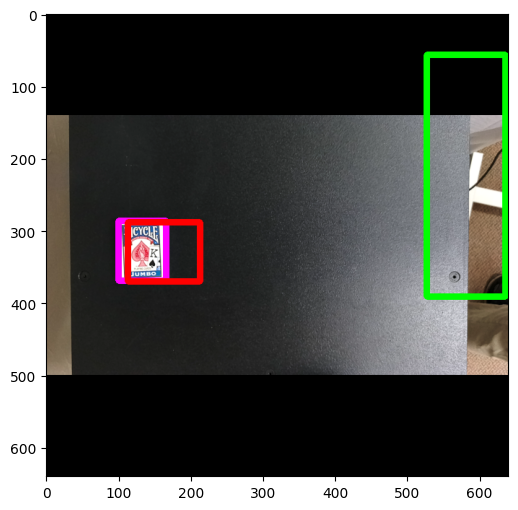

In [96]:
# draw evaluations
import matplotlib.pyplot as plt
from yolox.utils import postprocess
from yolox.data.datasets import OBBDataset
from yolox.data.data_augment import ValTransform
import numpy as np
import cv2

val_dataset = OBBDataset(
    data_dir="/content/YOLOX-OneShot/datasets/OBB360",  # folder containing images
    json_file="instances_obb2aabb_val2017.json",
    name="val2017",
    img_size=(640, 640),
    preproc=ValTransform(),  # ensures images are resized and normalized
)

val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=1, shuffle=False, num_workers=0
)

# helper to draw boxes
def draw_boxes(img, boxes, color=(0, 255, 0), thickness=8, mode=False):
    """Draw axis-aligned boxes on image"""
    for box in boxes:
        x_c, y_c, w, h = box[:4]
        if mode:
            x1 = int(x_c - w/2)
            y1 = int(y_c - h/2)
            x2 = int(x_c + w/2)
            y2 = int(y_c + h/2)
        else:
            x1 = int(x_c)
            y1 = int(y_c)
            x2 = int(x_c + w)
            y2 = int(y_c + h)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    return img

pred_colors = {
    0: (0, 0, 255),   # Red      candy
    1: (0, 255, 0),   # Green    cards
    2: (255, 0, 0),   # Blue     cheetos
}
gt_color = (255, 0, 255)  # Pink for ground truth

I = 17

for idx, (imgs, labels, info_imgs, ids) in enumerate(val_loader):
    if idx < I:
        continue
    if idx > I:
        break

    imgs = imgs.float()

    with torch.no_grad():
        raw_preds = model(imgs)

    preds = postprocess(raw_preds, num_classes=exp.num_classes, conf_thre=0.5, nms_thre=0.5)

    img = imgs[0].cpu().numpy().transpose(1,2,0)   # CHW -> HWC
    img = np.clip(img, 0, 255).astype(np.uint8)
    vis_img = img.copy()

    # Draw GT boxes (labels are already in pixels)
    num_gt = (labels.sum(dim=2) > 0).sum().item()
    labels_np = labels[0, :num_gt, :4].cpu().numpy()  # xc,yc,w,h
    vis_img = draw_boxes(vis_img, labels_np, gt_color, mode=True)

    # Draw predicted boxes
    print(f"idx={idx}: preds={preds}")
    if preds[0] is not None:
        # preds[0] shape: [num_dets, 6] -> [x1, y1, x2, y2, score, class]
        dets = preds[0].cpu().numpy()
        classes = dets[:, 6]
        # convert x1,y1,x2,y2 to xc,yc,w,h
        pred_boxes = np.zeros((dets.shape[0], 4))
        pred_boxes[:, 0] = (dets[:,0] + dets[:,2]) / 2  # xc
        pred_boxes[:, 1] = (dets[:,1] + dets[:,3]) / 2  # yc
        pred_boxes[:, 2] = dets[:,2] - dets[:,0]        # w
        pred_boxes[:, 3] = dets[:,3] - dets[:,1]        # h
        for i in range(dets.shape[0]):
          vis_img = draw_boxes(vis_img, [pred_boxes[i,:]], color=pred_colors[classes[i]], mode=True)

    # Convert BGR -> RGB for matplotlib
    img_viz = cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,6))
    plt.imshow(img_viz)
    plt.show()


In [97]:
# save the best model
from google.colab import files
files.download('/content/YOLOX-fork/YOLOX_outputs/yolox_s_obb_3classes/best_ckpt.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [98]:
# evaluate with the validation set
%cd /content/YOLOX-fork
!python -m yolox.tools.eval \
-f exps/example/custom/yolox_s_obb_3classes.py \
-c YOLOX_outputs/yolox_s_obb_3classes/best_ckpt.pth \
-b 8 \
-d 1 \
--conf 0.001

/content/YOLOX-fork
2026-03-14 07:38:08.513269: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773473888.534861   82654 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773473888.542217   82654 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773473888.561430   82654 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773473888.561458   82654 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773473888.561462   82654 computation_placer.cc:177] co

In [99]:
# show annotated images from validation set
%cd /content/YOLOX-fork
!python tools/demo.py image \
    -f exps/example/custom/yolox_s_obb_3classes.py \
    -c YOLOX_outputs/yolox_s_obb_3classes/best_ckpt.pth \
    --path ../YOLOX-OneShot/datasets/OBB360/val2017 \
    --conf 0.5 \
    --tsize 640 \
    --save_result \
    --device cuda

/content/YOLOX-fork
BLO - Turned off all augmentations
2026-03-14 07:38:41.902 | INFO     | __main__:main:262 - Args: Namespace(demo='image', experiment_name='yolox_s_obb_3classes', name=None, path='../YOLOX-OneShot/datasets/OBB360/val2017', camid=0, save_result=True, exp_file='exps/example/custom/yolox_s_obb_3classes.py', ckpt='YOLOX_outputs/yolox_s_obb_3classes/best_ckpt.pth', device='cuda', conf=0.5, nms=0.3, tsize=640, fp16=False, legacy=False, fuse=False, trt=False)
2026-03-14 07:38:42.146 | INFO     | __main__:main:272 - Model Summary: Params: 8.94M, Gflops: 26.76
2026-03-14 07:38:42.148 | INFO     | __main__:main:285 - loading checkpoint
2026-03-14 07:38:42.349 | INFO     | __main__:main:290 - loaded checkpoint done.
BLO boxes.py postprocess first box (xc,yc,w,h,obj): tensor([ 1.1667e-02, -2.7336e-02,  7.1790e+00,  8.7299e+00,  1.6522e-06])
2026-03-14 07:38:42.792 | INFO     | __main__:inference:168 - Infer time: 0.4298s
2026-03-14 07:38:42.793 | INFO     | __main__:image_demo:2

In [70]:
# save the annotated images
# zip the directory
!zip -r yolox_obb360_val_annotated.zip ./YOLOX_outputs/yolox_s_obb_3classes/vis_res/
from google.colab import files
files.download("yolox_obb360_val_annotated.zip")

  adding: YOLOX_outputs/yolox_s_obb_3classes/vis_res/ (stored 0%)
  adding: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/ (stored 0%)
  adding: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/cards.200.06_640x640.png (deflated 3%)
  adding: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/cheetos.600.57_640x640.png (deflated 3%)
  adding: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/cheetos.300.08_640x640.png (deflated 2%)
  adding: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/candy.600.05_640x640.png (deflated 3%)
  adding: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/three.600.51_640x640.png (deflated 3%)
  adding: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/candy.300.13_640x640.png (deflated 2%)
  adding: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/cheetos.600.54_640x640.png (deflated 3%)
  adding: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [100]:
# show annotated images from training set
%cd /content/YOLOX-fork
!python tools/demo.py image \
    -f exps/example/custom/yolox_s_obb_3classes.py \
    -c YOLOX_outputs/yolox_s_obb_3classes/best_ckpt.pth \
    --path ../YOLOX-OneShot/datasets/OBB360/train2017 \
    --conf 0.5 \
    --tsize 640 \
    --save_result \
    --device cuda

/content/YOLOX-fork
BLO - Turned off all augmentations
2026-03-14 07:39:07.824 | INFO     | __main__:main:262 - Args: Namespace(demo='image', experiment_name='yolox_s_obb_3classes', name=None, path='../YOLOX-OneShot/datasets/OBB360/train2017', camid=0, save_result=True, exp_file='exps/example/custom/yolox_s_obb_3classes.py', ckpt='YOLOX_outputs/yolox_s_obb_3classes/best_ckpt.pth', device='cuda', conf=0.5, nms=0.3, tsize=640, fp16=False, legacy=False, fuse=False, trt=False)
2026-03-14 07:39:08.070 | INFO     | __main__:main:272 - Model Summary: Params: 8.94M, Gflops: 26.76
2026-03-14 07:39:08.071 | INFO     | __main__:main:285 - loading checkpoint
2026-03-14 07:39:08.267 | INFO     | __main__:main:290 - loaded checkpoint done.
BLO boxes.py postprocess first box (xc,yc,w,h,obj): tensor([ 1.0306e-02, -2.9334e-02,  7.1789e+00,  8.7334e+00,  1.6510e-06])
2026-03-14 07:39:08.715 | INFO     | __main__:inference:168 - Infer time: 0.4346s
2026-03-14 07:39:08.715 | INFO     | __main__:image_demo

In [101]:
# save the annotated images
# zip the directory
!zip -r yolox_obb360_train_annotated.zip ./YOLOX_outputs/yolox_s_obb_3classes/vis_res/
from google.colab import files
files.download("yolox_obb360_train_annotated.zip")

updating: YOLOX_outputs/yolox_s_obb_3classes/vis_res/ (stored 0%)
updating: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/ (stored 0%)
updating: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/cards.200.06_640x640.png (deflated 3%)
updating: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/cheetos.600.57_640x640.png (deflated 3%)
updating: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/cheetos.300.08_640x640.png (deflated 2%)
updating: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/candy.600.05_640x640.png (deflated 3%)
updating: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/three.600.51_640x640.png (deflated 3%)
updating: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/candy.300.13_640x640.png (deflated 2%)
updating: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_03_14_05_21_26/cheetos.600.54_640x640.png (deflated 3%)
updating: YOLOX_outputs/yolox_s_obb_3classes/vis_res/2026_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>